In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.strategy import momentum_strategy
from src.backtest import backtest, results_table, optimize
from src.visualization import plot_performance


In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


## Momentum Strategy, Window = 5

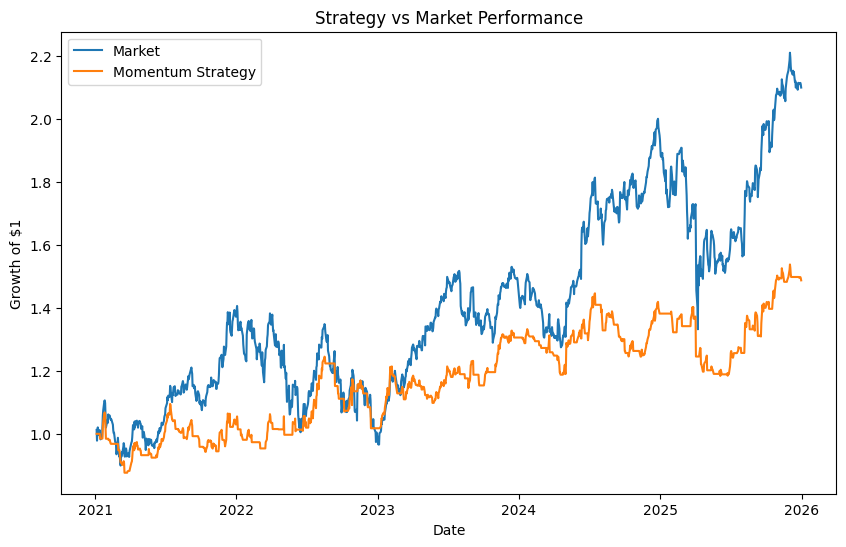

In [3]:
df = base_df.copy()
df = momentum_strategy(df, 5)
df = backtest(df)

plot_performance(df)

In [4]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN,NaN
1,Momentum,0.532690,0.180540,-0.182804,0.493227,0.520408,0.537651,54.661355


## Momentum Strategy, Window = 10

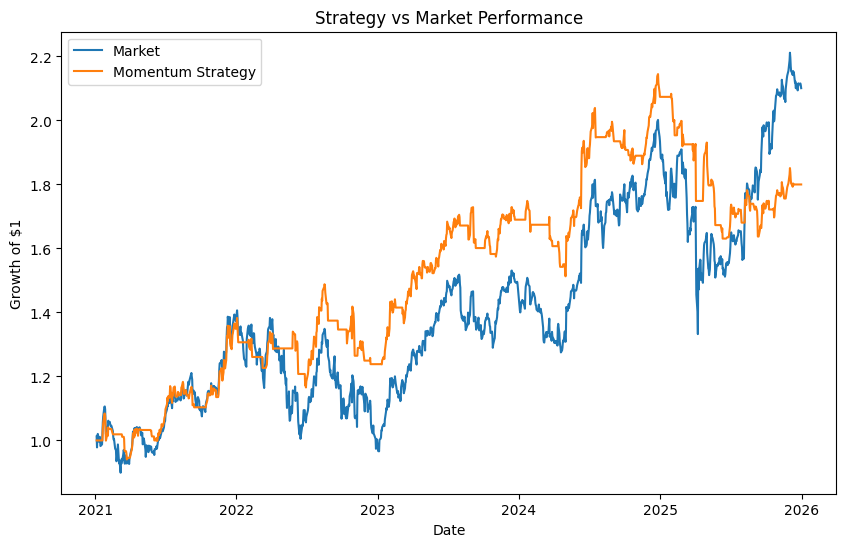

In [5]:
df = base_df.copy()
df = momentum_strategy(df)
df = backtest(df)

plot_performance(df)

In [6]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN,NaN
1,Momentum,0.743253,0.180892,-0.239679,0.514741,0.538678,0.576807,56.653386


## Momentum Strategy, Window = 20

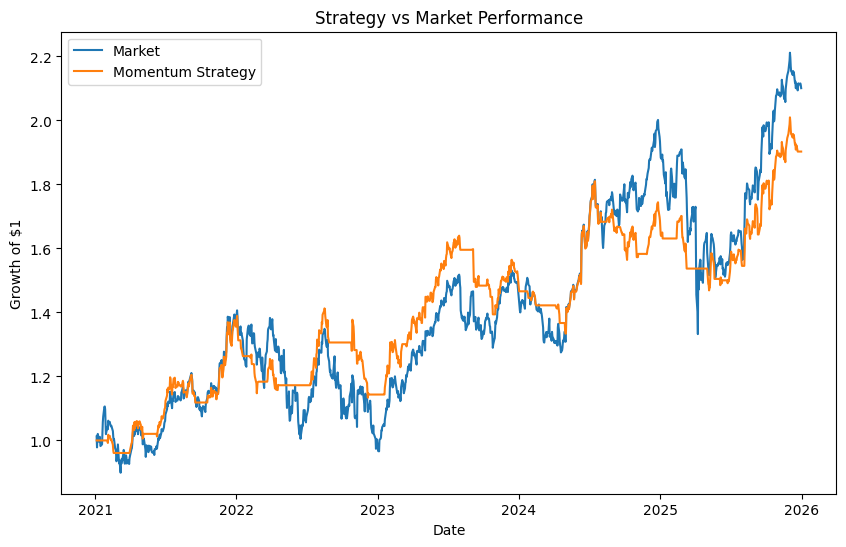

In [7]:
df = base_df.copy()
df = momentum_strategy(df, window = 20)
df = backtest(df)


plot_performance(df)

In [8]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN,NaN
1,Momentum,0.822887,0.175712,-0.197545,0.491633,0.51752,0.578313,59.123506


## Momentum Strategy, Window = 50

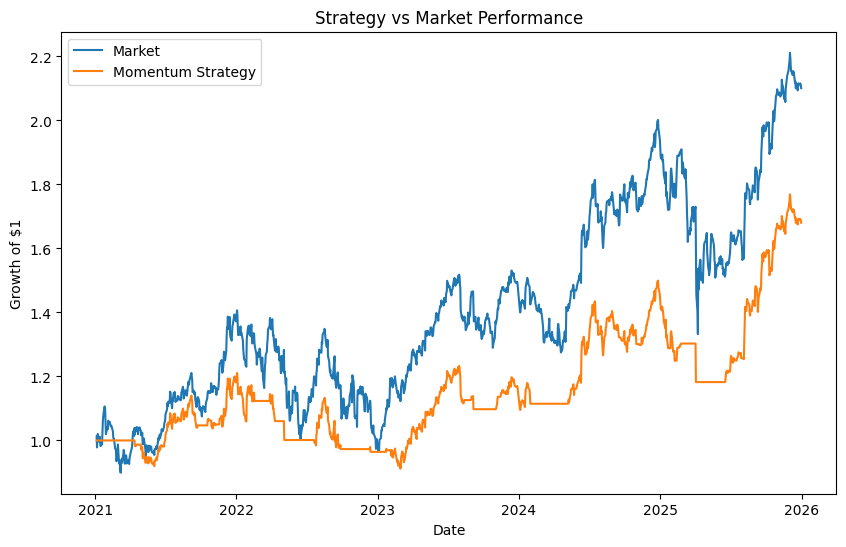

In [9]:
df = base_df.copy()
df = momentum_strategy(df, window = 50)
df = backtest(df)


plot_performance(df)

In [10]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN,NaN
1,Momentum,0.671191,0.179313,-0.246886,0.505976,0.530137,0.582831,58.167331


## Window Test

Momentum
Market Sharpe Ratio: 0.6742
Best Momentum Strategy window: 6
Best Sharpe ratio: 0.9757



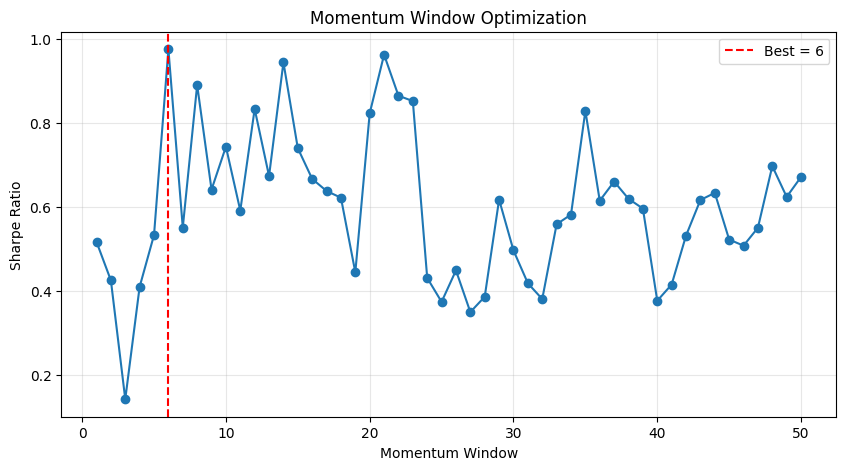

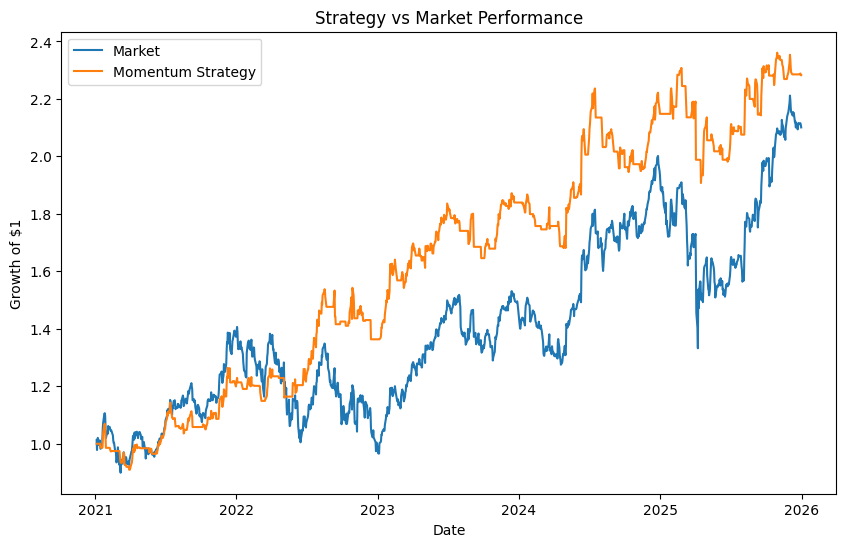

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN,NaN
1,Momentum,0.975684,0.188123,-0.173479,0.508367,0.533716,0.560241,55.537849


In [11]:
df = base_df.copy()
strategy = [
    ('Momentum', momentum_strategy, 'mom', None, None)
]
window = range(1, 51)
optimize(df, strategy, window)